In [916]:
from article_xas_xncd.class_spectrum import *
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib as mpl
from collections import OrderedDict
from matplotlib.ticker import ScalarFormatter
from matplotlib.transforms import ScaledTranslation

# Global switch:
# - True: rebuild Spectrum objects and overwrite cache
# - False: load previously cached Spectrum objects
REBUILD_SPECTRUM_CACHE = False
SPECTRUM_CACHE_DIR = Path("/home/sanchez/Trieste_Project/Chemistry/Scripts/article_xas_xncd/data") / ".spectrum_cache"
SPECTRUM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

_Spectrum_original = Spectrum


def _spectrum_cache_path(args, kwargs, cache_tag=None):
    """Build a deterministic cache path for a Spectrum call."""
    if cache_tag is None:
        payload = pickle.dumps((args, kwargs), protocol=pickle.HIGHEST_PROTOCOL)
        cache_tag = hashlib.sha256(payload).hexdigest()
    return SPECTRUM_CACHE_DIR / f"spectrum_{cache_tag}.pkl"


def load_or_build_spectrum(*args, force_rebuild=REBUILD_SPECTRUM_CACHE, cache_tag=None, **kwargs):
    """Load Spectrum from cache or build and store it."""
    cache_path = _spectrum_cache_path(args, kwargs, cache_tag=cache_tag)

    if force_rebuild:
        spectrum_obj = _Spectrum_original(*args, **kwargs)
        with cache_path.open("wb") as f:
            pickle.dump(spectrum_obj, f, protocol=pickle.HIGHEST_PROTOCOL)
        return spectrum_obj

    if cache_path.exists():
        with cache_path.open("rb") as f:
            return pickle.load(f)

    raise FileNotFoundError(
        f"Spectrum cache not found at {cache_path}. "
        "Set REBUILD_SPECTRUM_CACHE=True once to generate it."
    )


# Apply globally to every Spectrum(...) call in this notebook.
Spectrum = load_or_build_spectrum

In [917]:
json_path = "/home/sanchez/Trieste_Project/Chemistry/Scripts/article_xas_xncd/data/paths.json"

with open(json_path, "r") as f:
    json_data = json.load(f)

In [918]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

import matplotlib.pyplot as plt

# Restore plt.figure if a previous session patched it (draw_event alignment caused huge PNGs).
if getattr(plt, "_article_xas_orig_figure", None) is not None:
    plt.figure = plt._article_xas_orig_figure

# Jupyter Inline backend defaults to bbox_inches="tight" when rasterizing figures; with twin
# axes / legends / offset text this can produce absurd pixel heights (ValueError).
try:
    _ipy = __import__("IPython").get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'bbox_inches': None}",
        )
except Exception:
    pass

if "savefig.bbox" in mpl.rcParams:
    mpl.rcParams["savefig.bbox"] = "standard"

In [919]:
conv_factor_pmm_au_xas = 1.36539*1E-4
conv_factor_pmm_au_xcd = 1.36539*1E-4

In [920]:
I = 1E4  # Intensity in W/cm^2
FWHM = 500  # FWHM in as # 1000
central_frequency = 278 # Pulse oscillation frequency in eV

pulse = Electric_Field_Pulse(I=I, dt=5E-3, pulse_type='gaussian_sin', FWHM=FWHM, omega_sin=central_frequency)
print(pulse)

Electric Field Pulse:
  Intensity (I): 10000.0 W/cm^2
  FWHM: 500 as
  Central frequency: 10.2163064009937 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 8.778032407146851 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 800000
  Pulse type: gaussian_sin
  Time at maximum: 44.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.
  


## XAS vs Energy: CAM-B3LYP, Gas-Phase vs $H_2O$ (1 figure with XAS (CAM: gas phase vs H2O) + structure)

In [921]:
data_gas_codiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_codiff"], color="black", label=r"Gas-Phase, C/O QZP Diffuse", limits=pulse.crossings_E)
E_gas_codiff = data_gas_codiff.av_CD_energy_eV
xcd_gas_codiff = data_gas_codiff.av_CD_spectrum
xas_gas_codiff = data_gas_codiff.av_lin_spectrum

data_water_codiff_camb3lyp = np.genfromtxt(json_data["path_spectra_xcd_camb3lyp_water_carbon_codiff_pmm"])
E_water_codiff_camb3lyp = data_water_codiff_camb3lyp[:,0]
xcd_water_codiff_camb3lyp = data_water_codiff_camb3lyp[:,1]

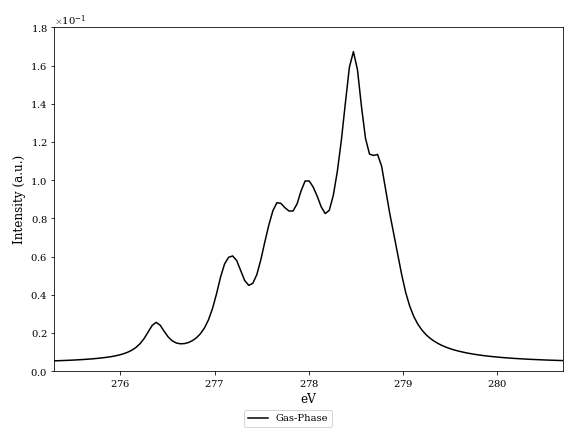

In [922]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff,
    xas_gas_codiff,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)

#line2, = ax.plot(
#    E_water_codiff_camb3lyp,
#    xas_water_codiff_camb3lyp*conv_factor_pmm_au_xas,
#    label=r"Solvent: $H_2O$",
#    color="blue",
#    linestyle="--",
#)

ax.set_xlim(275.3, 280.7)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)", color="black")
ax.tick_params(axis="y", labelcolor="black")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax.set_ylim(0.0, 0.18)

lines = [line1]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XCD vs Energy: CAM-B3LYP, Gas-Phase vs $H_2O$ (1 figure with XCD (CAM: gas phase vs H2O))

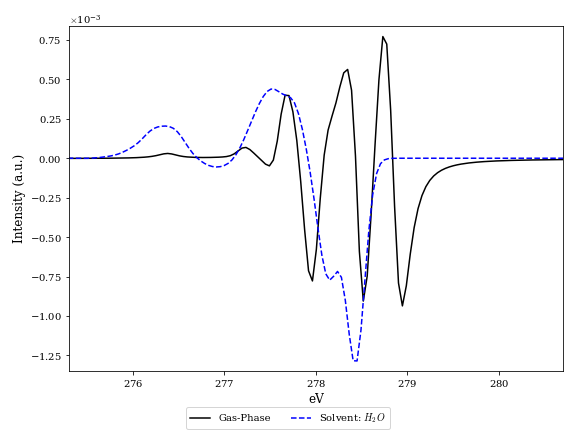

In [923]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff,
    xcd_gas_codiff,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)
line2, = ax.plot(
    E_water_codiff_camb3lyp,
    xcd_water_codiff_camb3lyp*conv_factor_pmm_au_xcd,
    label=r"Solvent: $H_2O$",
    color="blue",
    linestyle="--",
)
ax.set_xlim(275.3, 280.7)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Single y-scale, centered at zero (same margin as before for both series).
y1_lim = np.nanmax(np.abs(xcd_gas_codiff))
y2_lim = np.nanmax(np.abs(xcd_water_codiff_camb3lyp*conv_factor_pmm_au_xcd))
y_max = max(y1_lim, y2_lim)
ax.set_ylim(-1.05 * y_max, 0.65 * y_max)

lines = [line1, line2]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XAS vs Energy: CAM-B3LYP, Gas-Phase vs Perfluorohexane (1 figure with XAS (CAM: gas phase vs perflurohexane))

In [924]:
data_perfluorohexane_codiff_camb3lyp = np.genfromtxt(json_data["path_spectra_xcd_camb3lyp_perfluorohexane_carbon_codiff_pmm"])
E_perfluorohexane_codiff_camb3lyp = data_perfluorohexane_codiff_camb3lyp[:,0]
xcd_perfluorohexane_codiff_camb3lyp = data_perfluorohexane_codiff_camb3lyp[:,1]

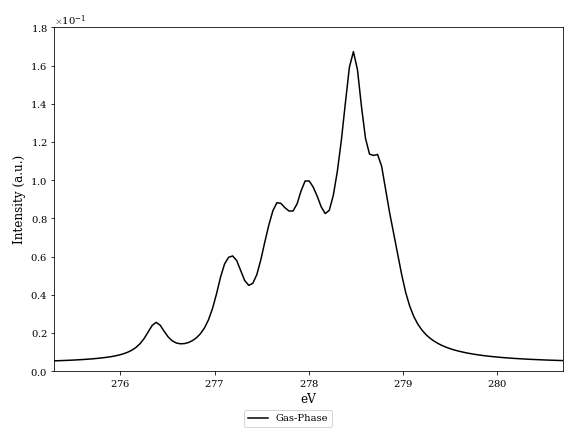

In [925]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff,
    xas_gas_codiff,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)

#line2, = ax.plot(
#    E_perfluorohexane_codiff_camb3lyp,
#    xas_perfluorohexane_codiff_camb3lyp*conv_factor_pmm_au_xas,
#    label=r"Solvent: $H_2O$",
#    color="blue",
#    linestyle="--",
#)

ax.set_xlim(275.3, 280.7)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)", color="black")
ax.tick_params(axis="y", labelcolor="black")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax.set_ylim(0.0, 0.18)

lines = [line1]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XCD vs Energy: CAM-B3LYP, Gas-Phase vs Perfluorohexane (1 figure with XCD (CAM: gas phase vs perfluorhexane))

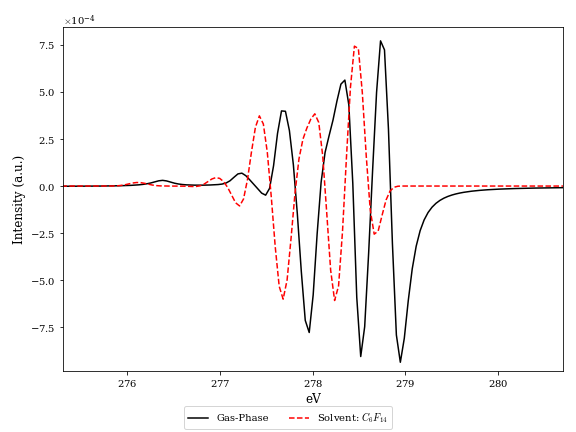

In [926]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff,
    xcd_gas_codiff,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)
line2, = ax.plot(
    E_perfluorohexane_codiff_camb3lyp,
    xcd_perfluorohexane_codiff_camb3lyp*conv_factor_pmm_au_xcd,
    label=r"Solvent: $C_6F_{14}$",
    color="red",
    linestyle="--",
)
ax.set_xlim(275.3, 280.7)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Single y-scale, centered at zero (same margin as before for both series).
y1_lim = np.nanmax(np.abs(xcd_gas_codiff))
y2_lim = np.nanmax(np.abs(xcd_perfluorohexane_codiff_camb3lyp*conv_factor_pmm_au_xcd))
y_max = max(y1_lim, y2_lim)
ax.set_ylim(-1.05 * y_max, 0.9 * y_max)

lines = [line1, line2]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XAS vs Energy: B3LYP, Gas-Phase vs $H_2O$, Supporting Info (Same figures with B3LYP in the Supporting Information)

In [927]:
data_gas_codiff_b3lyp = Spectrum(project=json_data["path_spectra_b3lyp_gas_carbon_codiff"], color="black", label=r"Gas-Phase, C/O QZP Diffuse", limits=pulse.crossings_E)
E_gas_codiff_b3lyp = data_gas_codiff_b3lyp.av_CD_energy_eV
xcd_gas_codiff_b3lyp = data_gas_codiff_b3lyp.av_CD_spectrum
xas_gas_codiff_b3lyp = data_gas_codiff_b3lyp.av_lin_spectrum

data_water_codiff_b3lyp = np.genfromtxt(json_data["path_spectra_xcd_b3lyp_water_carbon_codiff_pmm"])
E_water_codiff_b3lyp = data_water_codiff_b3lyp[:,0]
xcd_water_codiff_b3lyp = data_water_codiff_b3lyp[:,1]

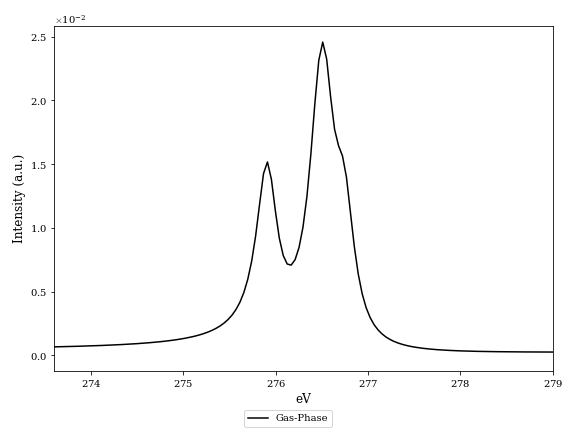

In [928]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff_b3lyp,
    xas_gas_codiff_b3lyp,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)

#line2, = ax.plot(
#    E_water_codiff_b3lyp,
#    xas_water_codiff_b3lyp*conv_factor_pmm_au_xas,
#    label=r"Solvent: $H_2O$",
#    color="blue",
#    linestyle="--",
#)

ax.set_xlim(273.6, 279)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)", color="black")
ax.tick_params(axis="y", labelcolor="black")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line1]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XCD vs Energy: B3LYP, Gas-Phase vs $H_2O$, Supporting Info ((Same figures with B3LYP in the Supporting Information))

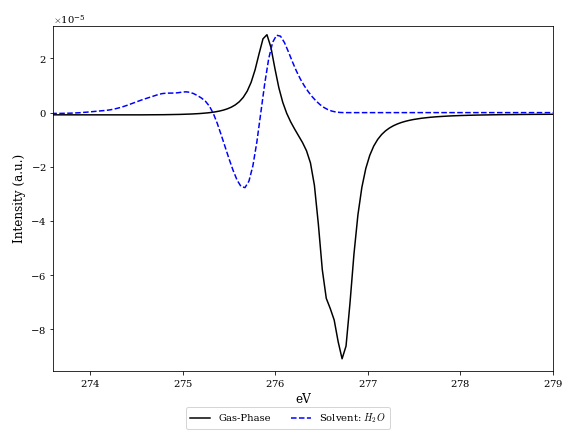

In [929]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff_b3lyp,
    xcd_gas_codiff_b3lyp,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)
line2, = ax.plot(
    E_water_codiff_b3lyp,
    xcd_water_codiff_b3lyp*conv_factor_pmm_au_xcd,
    label=r"Solvent: $H_2O$",
    color="blue",
    linestyle="--",
)
ax.set_xlim(273.6, 279)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Single y-scale, centered at zero (same margin as before for both series).
y1_lim = np.nanmax(np.abs(xcd_gas_codiff_b3lyp))
y2_lim = np.nanmax(np.abs(xcd_water_codiff_b3lyp*conv_factor_pmm_au_xcd))
y_max = max(y1_lim, y2_lim)
ax.set_ylim(-1.05 * y_max, 0.35 * y_max)

lines = [line1, line2]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XAS vs Energy: B3LYP, Gas-Phase vs Perfluorohexane, Supporting Info (Same figures with B3LYP in the Supporting Information)

In [930]:
data_perfluorohexane_codiff_b3lyp = np.genfromtxt(json_data["path_spectra_xcd_b3lyp_perfluorohexane_carbon_codiff_pmm"])
E_perfluorohexane_codiff_b3lyp = data_perfluorohexane_codiff_b3lyp[:,0]
xcd_perfluorohexane_codiff_b3lyp = data_perfluorohexane_codiff_b3lyp[:,1]

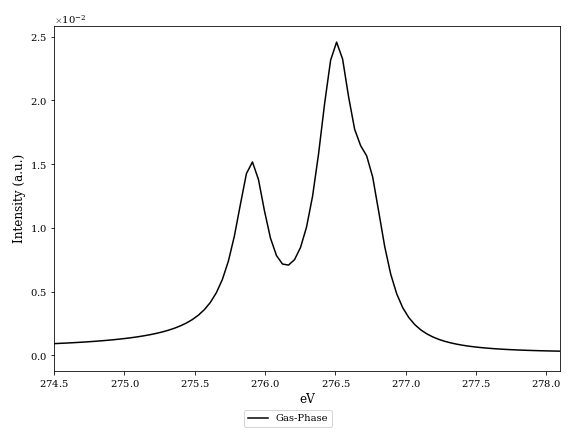

In [931]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff_b3lyp,
    xas_gas_codiff_b3lyp,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)

#line2, = ax.plot(
#    E_perfluorohexane_codiff_b3lyp,
#    xas_perfluorohexane_codiff_b3lyp*conv_factor_pmm_au_xas,
#    label=r"Solvent: $C_6F_{14}$",
#    color="red",
#    linestyle="--",
#)

ax.set_xlim(274.5, 278.1)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)", color="black")
ax.tick_params(axis="y", labelcolor="black")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line1]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XCD vs Energy: B3LYP, Gas-Phase vs Perfluorohexane, Supporting Info (Same figures with B3LYP in the Supporting Information)

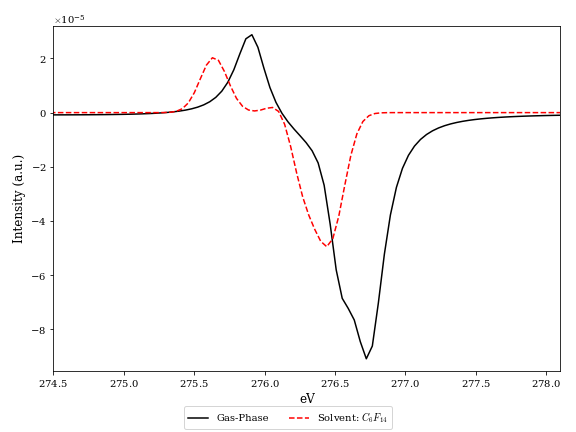

In [932]:
fig, ax = plt.subplots(figsize=(8, 6))

line1, = ax.plot(
    E_gas_codiff_b3lyp,
    xcd_gas_codiff_b3lyp,
    label="Gas-Phase",
    color="black",
    linestyle="-",
)
line2, = ax.plot(
    E_perfluorohexane_codiff_b3lyp,
    xcd_perfluorohexane_codiff_b3lyp*conv_factor_pmm_au_xcd,
    label=r"Solvent: $C_6F_{14}$",
    color="red",
    linestyle="--",
)
ax.set_xlim(274.5, 278.1)
ax.set_xlabel("eV")
ax.set_ylabel("Intensity (a.u.)")
ax.ticklabel_format(style="plain", axis="x", useMathText=True)
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Single y-scale (same margin as CAM for both series).
y1_lim = np.nanmax(np.abs(xcd_gas_codiff_b3lyp))
y2_lim = np.nanmax(np.abs(xcd_perfluorohexane_codiff_b3lyp*conv_factor_pmm_au_xcd))
y_max = max(y1_lim, y2_lim)
ax.set_ylim(-1.05 * y_max, 0.35 * y_max)

lines = [line1, line2]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## Comparison PMM vs PCM: XAS and XCD (comparison with PCM: 1 Figure with panels XAS and XCD PCM vs PMM (H2O))

In [933]:
data_water_codiff_pcm_b3lyp = Spectrum(project=json_data["path_spectra_b3lyp_water_carbon_codiff_pcm"], color="black", label=r"Water, C/O QZP Diffuse", limits=pulse.crossings_E)
E_water_xcd_codiff_pcm_b3lyp = data_water_codiff_pcm_b3lyp.av_CD_energy_eV
xcd_water_codiff_pcm_b3lyp = data_water_codiff_pcm_b3lyp.av_CD_spectrum
xas_water_codiff_pcm_b3lyp = data_water_codiff_pcm_b3lyp.av_lin_spectrum
E_water_xas_codiff_pcm_b3lyp = data_water_codiff_pcm_b3lyp.av_lin_energy_eV

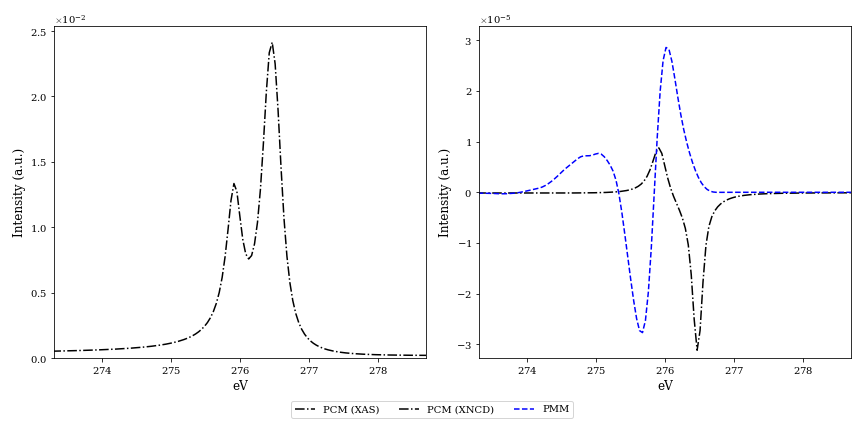

In [934]:
fig = plt.figure(figsize=(12, 6))

shift_pmm_E = 0.0#-0.45  # eV

ax1 = plt.subplot(1, 2, 1)
line_xas_pcm, = ax1.plot(
    E_water_xas_codiff_pcm_b3lyp,
    xas_water_codiff_pcm_b3lyp,
    color="black",
    linestyle="-.",
    label=r"PCM (XAS)",
)
ax1.set_xlim(273.3, 278.7)
ax1.set_xlabel("eV")
ax1.set_ylabel("Intensity (a.u.)")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
y1_max = np.nanmax(xas_water_codiff_pcm_b3lyp)
ax1.set_ylim(0.0, 1.05 * y1_max)

ax2 = plt.subplot(1, 2, 2)
line_pcm, = ax2.plot(
    E_water_xcd_codiff_pcm_b3lyp,
    xcd_water_codiff_pcm_b3lyp,
    color="black",
    linestyle="-.",
    label=r"PCM (XNCD)",
)
line_pmm, = ax2.plot(
    E_water_codiff_b3lyp - shift_pmm_E,
    xcd_water_codiff_b3lyp * conv_factor_pmm_au_xcd,
    color="blue",
    linestyle="--",
    label="PMM",
)
ax2.set_xlim(273.3, 278.7)
ax2.set_xlabel("eV")
ax2.set_ylabel("Intensity (a.u.)")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

y2_pcm_lim = np.nanmax(np.abs(xcd_water_codiff_pcm_b3lyp))
y2_pmm_lim = np.nanmax(np.abs(xcd_water_codiff_b3lyp * conv_factor_pmm_au_xcd))
y2_max = max(y2_pcm_lim, y2_pmm_lim)
ax2.set_ylim(-1.05 * y2_max, 1.05 * y2_max)

lines = [line_xas_pcm, line_pcm, line_pmm]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.06, 1, 1))

In [935]:
data_water_codiff_pcm_camb3lyp = Spectrum(project=json_data["path_spectra_camb3lyp_water_carbon_codiff_pcm"], color="black", label=r"Water, C/O QZP Diffuse", limits=pulse.crossings_E)
E_water_xcd_codiff_pcm_camb3lyp = data_water_codiff_pcm_camb3lyp.av_CD_energy_eV
xcd_water_codiff_pcm_camb3lyp = data_water_codiff_pcm_camb3lyp.av_CD_spectrum
xas_water_codiff_pcm_camb3lyp = data_water_codiff_pcm_camb3lyp.av_lin_spectrum
E_water_xas_codiff_pcm_camb3lyp = data_water_codiff_pcm_camb3lyp.av_lin_energy_eV

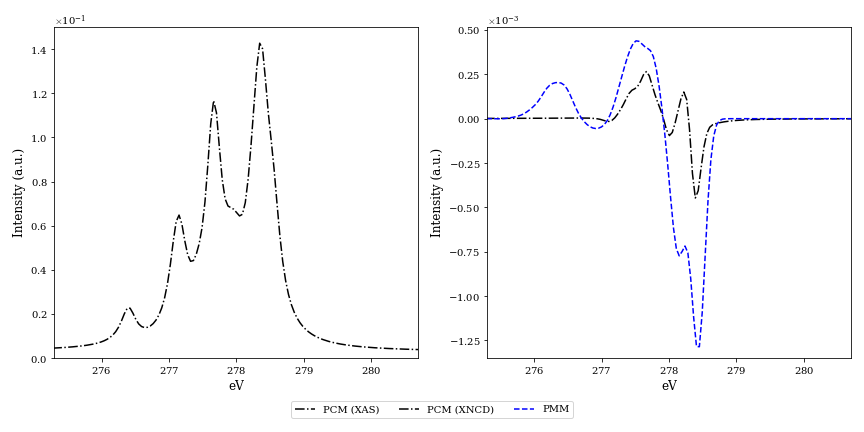

In [956]:
fig = plt.figure(figsize=(12, 6))

shift_pmm_E = 0.0  # eV

ax1 = plt.subplot(1, 2, 1)
line_xas_pcm, = ax1.plot(
    E_water_xas_codiff_pcm_camb3lyp,
    xas_water_codiff_pcm_camb3lyp,
    color="black",
    linestyle="-.",
    label=r"PCM (XAS)",
)
ax1.set_xlim(275.3, 280.7)
ax1.set_xlabel("eV")
ax1.set_ylabel("Intensity (a.u.)")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
y1_max = np.nanmax(xas_water_codiff_pcm_camb3lyp)
ax1.set_ylim(0.0, 1.05 * y1_max)

ax2 = plt.subplot(1, 2, 2)
line_pcm, = ax2.plot(
    E_water_xcd_codiff_pcm_camb3lyp,
    xcd_water_codiff_pcm_camb3lyp,
    color="black",
    linestyle="-.",
    label=r"PCM (XNCD)",
)
line_pmm, = ax2.plot(
    E_water_codiff_camb3lyp - shift_pmm_E,
    xcd_water_codiff_camb3lyp * conv_factor_pmm_au_xcd,
    color="blue",
    linestyle="--",
    label="PMM",
)
ax2.set_xlim(275.3, 280.7)
ax2.set_xlabel("eV")
ax2.set_ylabel("Intensity (a.u.)")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

y2_pcm_lim = np.nanmax(np.abs(xcd_water_codiff_pcm_camb3lyp))
y2_pmm_lim = np.nanmax(np.abs(xcd_water_codiff_camb3lyp * conv_factor_pmm_au_xcd))
y2_max = max(y2_pcm_lim, y2_pmm_lim)
ax2.set_ylim(-1.05 * y2_max, 0.4 * y2_max)

lines = [line_xas_pcm, line_pcm, line_pmm]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.06, 1, 1))

# Excited State

## Basis set convergence - Excited State, Left: LG XAS for different basis sets. Right: VG XAS for different basis sets

### BS1: C QZP 1 Diffuse, O and H TZP
### BS2: C and O QZP 1 Diffuse, H TZP
### BS3: C and O TZP Diffuse, H TZP

### Core: BSI, BS2, BS3. Valence: All TZP

# One Figure, two panels: XAS from first-excited state, basis set convergence in LG (left panel) and in VG (right panel)

In [937]:
ES_params = {"n_roots_core": 60, "n_roots_valence": 60, "n_roots_core_eff": 17, "n_roots_valence_eff": 60, "region": "core", "limits": [0,300]}

data_gas_bs1_es_lg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_es_lg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS1, LG", limits=pulse.crossings_E)
E_gas_xcd_bs1_es_lg_vcdiff = data_gas_bs1_es_lg_vcdiff.av_CD_energy_eV
xcd_bs1_es_lg_vcdiff = data_gas_bs1_es_lg_vcdiff.av_CD_spectrum
E_gas_xas_bs1_es_lg_vcdiff = data_gas_bs1_es_lg_vcdiff.av_lin_energy_eV
xas_bs1_es_lg_vcdiff = data_gas_bs1_es_lg_vcdiff.av_lin_spectrum

data_gas_bs1_es_vg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_es_vg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS1, VG", limits=pulse.crossings_E)
E_gas_xcd_bs1_es_vg_vcdiff = data_gas_bs1_es_vg_vcdiff.av_CD_energy_eV
xcd_bs1_es_vg_vcdiff = data_gas_bs1_es_vg_vcdiff.av_CD_spectrum
E_gas_xas_bs1_es_vg_vcdiff = data_gas_bs1_es_vg_vcdiff.av_lin_energy_eV
xas_bs1_es_vg_vcdiff = data_gas_bs1_es_vg_vcdiff.av_lin_spectrum

data_gas_bs2_es_lg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_es_lg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS2, LG", limits=pulse.crossings_E)
E_gas_xcd_bs2_es_lg_vcdiff = data_gas_bs2_es_lg_vcdiff.av_CD_energy_eV
xcd_bs2_es_lg_vcdiff = data_gas_bs2_es_lg_vcdiff.av_CD_spectrum
E_gas_xas_bs2_es_lg_vcdiff = data_gas_bs2_es_lg_vcdiff.av_lin_energy_eV
xas_bs2_es_lg_vcdiff = data_gas_bs2_es_lg_vcdiff.av_lin_spectrum

data_gas_bs2_es_vg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_es_vg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS2, VG", limits=pulse.crossings_E)
E_gas_xcd_bs2_es_vg_vcdiff = data_gas_bs2_es_vg_vcdiff.av_CD_energy_eV
xcd_bs2_es_vg_vcdiff = data_gas_bs2_es_vg_vcdiff.av_CD_spectrum
E_gas_xas_bs2_es_vg_vcdiff = data_gas_bs2_es_vg_vcdiff.av_lin_energy_eV
xas_bs2_es_vg_vcdiff = data_gas_bs2_es_vg_vcdiff.av_lin_spectrum

data_gas_bs3_es_lg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_es_lg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS3, LG", limits=pulse.crossings_E)
E_gas_xcd_bs3_es_lg_vcdiff = data_gas_bs3_es_lg_vcdiff.av_CD_energy_eV
xcd_bs3_es_lg_vcdiff = data_gas_bs3_es_lg_vcdiff.av_CD_spectrum
E_gas_xas_bs3_es_lg_vcdiff = data_gas_bs3_es_lg_vcdiff.av_lin_energy_eV
xas_bs3_es_lg_vcdiff = data_gas_bs3_es_lg_vcdiff.av_lin_spectrum

data_gas_bs3_es_vg_vcdiff = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_es_vg_vcdiff"], ES_parameters=ES_params, color="black", label=r"GAS, BS3, VG", limits=pulse.crossings_E)
E_gas_xcd_bs3_es_vg_vcdiff = data_gas_bs3_es_vg_vcdiff.av_CD_energy_eV
xcd_bs3_es_vg_vcdiff = data_gas_bs3_es_vg_vcdiff.av_CD_spectrum
E_gas_xas_bs3_es_vg_vcdiff = data_gas_bs3_es_vg_vcdiff.av_lin_energy_eV
xas_bs3_es_vg_vcdiff = data_gas_bs3_es_vg_vcdiff.av_lin_spectrum



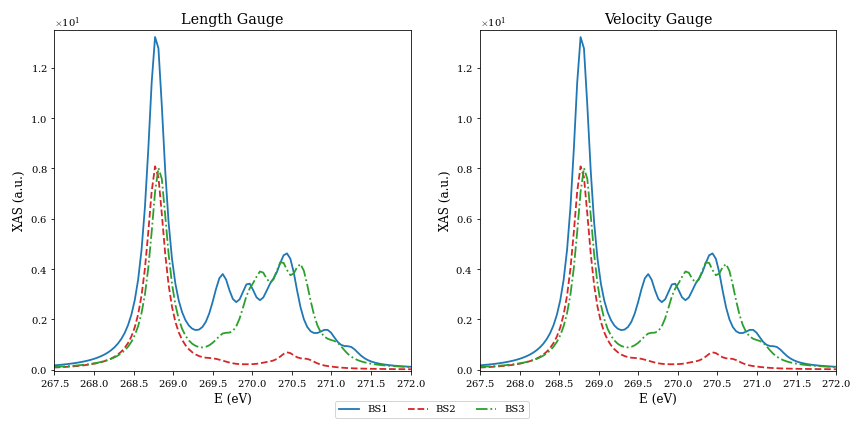

In [938]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 1.8},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.8},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.8},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xas_bs1_es_lg_vcdiff, xas_bs1_es_lg_vcdiff, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xas_bs2_es_lg_vcdiff, xas_bs2_es_lg_vcdiff, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xas_bs3_es_lg_vcdiff, 450*xas_bs3_es_lg_vcdiff, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(267.5, 272)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XAS (a.u.)")
ax1.set_ylim(-0.05, 13.5)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xas_bs1_es_vg_vcdiff, xas_bs1_es_vg_vcdiff, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xas_bs2_es_vg_vcdiff, xas_bs2_es_vg_vcdiff, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xas_bs3_es_vg_vcdiff, 450*xas_bs3_es_vg_vcdiff, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(267.5, 272)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XAS (a.u.)")
ax2.set_ylim(-0.05, 13.5)
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

# One Figure, two panels: XCD from first-excited state, basis set convergence in LG (left panel) and in VG (right panel)

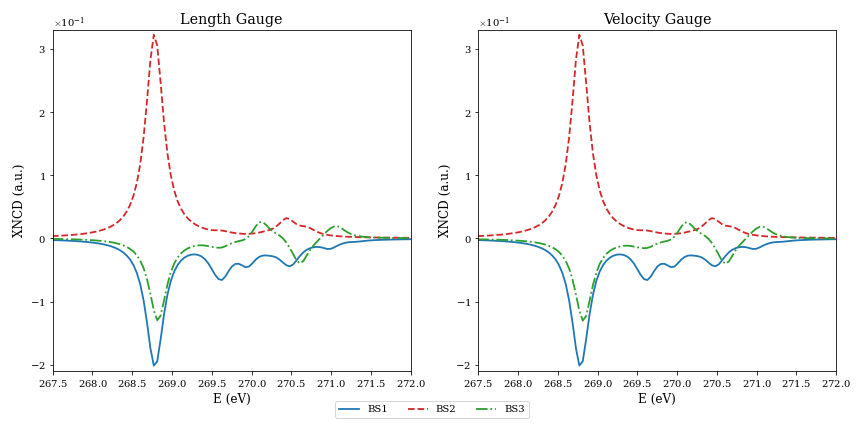

In [939]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 1.8},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.8},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.8},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xcd_bs1_es_lg_vcdiff, xcd_bs1_es_lg_vcdiff, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xcd_bs2_es_lg_vcdiff, xcd_bs2_es_lg_vcdiff, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xcd_bs3_es_lg_vcdiff, 450*xcd_bs3_es_lg_vcdiff, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(267.5, 272)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XNCD (a.u.)")
ax1.set_ylim(-0.21, 0.33)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xcd_bs1_es_vg_vcdiff, xcd_bs1_es_vg_vcdiff, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xcd_bs2_es_vg_vcdiff, xcd_bs2_es_vg_vcdiff, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xcd_bs3_es_vg_vcdiff, 450*xcd_bs3_es_vg_vcdiff, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(267.5, 272)
ax2.set_ylim(-0.21, 0.33)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XNCD (a.u.)")
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

# One Figure, two panels: XAS from first-excited state, basis set convergence in LG (left panel) and in VG (right panel)

### Core: BSI, BS2, BS3. Valence: BSI, BS2, BS3

In [940]:
ES_params = {"n_roots_core": 60, "n_roots_valence": 60, "n_roots_core_eff": 17, "n_roots_valence_eff": 60, "region": "core", "limits": [0,300]}

data_gas_bs1_es_lg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_es_lg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS1, LG", limits=pulse.crossings_E)
E_gas_xcd_bs1_es_lg_vcsame = data_gas_bs1_es_lg_vcsame.av_CD_energy_eV
xcd_bs1_es_lg_vcsame = data_gas_bs1_es_lg_vcsame.av_CD_spectrum
E_gas_xas_bs1_es_lg_vcsame = data_gas_bs1_es_lg_vcsame.av_lin_energy_eV
xas_bs1_es_lg_vcsame = data_gas_bs1_es_lg_vcsame.av_lin_spectrum

data_gas_bs1_es_vg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_es_vg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS1, VG", limits=pulse.crossings_E)
E_gas_xcd_bs1_es_vg_vcsame = data_gas_bs1_es_vg_vcsame.av_CD_energy_eV
xcd_bs1_es_vg_vcsame = data_gas_bs1_es_vg_vcsame.av_CD_spectrum
E_gas_xas_bs1_es_vg_vcsame = data_gas_bs1_es_vg_vcsame.av_lin_energy_eV
xas_bs1_es_vg_vcsame = data_gas_bs1_es_vg_vcsame.av_lin_spectrum

data_gas_bs2_es_lg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_es_lg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS2, LG", limits=pulse.crossings_E)
E_gas_xcd_bs2_es_lg_vcsame = data_gas_bs2_es_lg_vcsame.av_CD_energy_eV
xcd_bs2_es_lg_vcsame = data_gas_bs2_es_lg_vcsame.av_CD_spectrum
E_gas_xas_bs2_es_lg_vcsame = data_gas_bs2_es_lg_vcsame.av_lin_energy_eV
xas_bs2_es_lg_vcsame = data_gas_bs2_es_lg_vcsame.av_lin_spectrum

data_gas_bs2_es_vg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_es_vg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS2, VG", limits=pulse.crossings_E)
E_gas_xcd_bs2_es_vg_vcsame = data_gas_bs2_es_vg_vcsame.av_CD_energy_eV
xcd_bs2_es_vg_vcsame = data_gas_bs2_es_vg_vcsame.av_CD_spectrum
E_gas_xas_bs2_es_vg_vcsame = data_gas_bs2_es_vg_vcsame.av_lin_energy_eV
xas_bs2_es_vg_vcsame = data_gas_bs2_es_vg_vcsame.av_lin_spectrum

data_gas_bs3_es_lg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_es_lg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS3, LG", limits=pulse.crossings_E)
E_gas_xcd_bs3_es_lg_vcsame = data_gas_bs3_es_lg_vcsame.av_CD_energy_eV
xcd_bs3_es_lg_vcsame = data_gas_bs3_es_lg_vcsame.av_CD_spectrum
E_gas_xas_bs3_es_lg_vcsame = data_gas_bs3_es_lg_vcsame.av_lin_energy_eV
xas_bs3_es_lg_vcsame = data_gas_bs3_es_lg_vcsame.av_lin_spectrum

data_gas_bs3_es_vg_vcsame = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_es_vg_vcsame"], ES_parameters=ES_params, color="black", label=r"GAS, BS3, VG", limits=pulse.crossings_E)
E_gas_xcd_bs3_es_vg_vcsame = data_gas_bs3_es_vg_vcsame.av_CD_energy_eV
xcd_bs3_es_vg_vcsame = data_gas_bs3_es_vg_vcsame.av_CD_spectrum
E_gas_xas_bs3_es_vg_vcsame = data_gas_bs3_es_vg_vcsame.av_lin_energy_eV
xas_bs3_es_vg_vcsame = data_gas_bs3_es_vg_vcsame.av_lin_spectrum



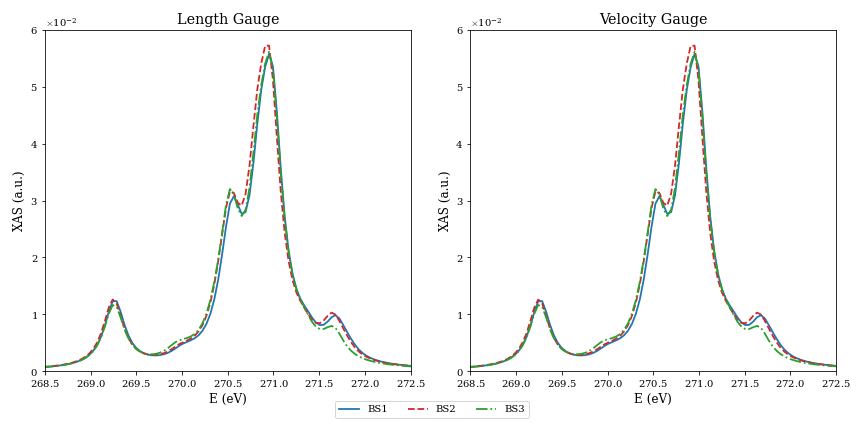

In [941]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 1.8},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.8},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.8},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xas_bs1_es_lg_vcsame, xas_bs1_es_lg_vcsame, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xas_bs2_es_lg_vcsame, xas_bs2_es_lg_vcsame, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xas_bs3_es_lg_vcsame, xas_bs3_es_lg_vcsame, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(268.5, 272.5)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XAS (a.u.)")
ax1.set_ylim(0, 0.06)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xas_bs1_es_vg_vcsame, xas_bs1_es_vg_vcsame, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xas_bs2_es_vg_vcsame, xas_bs2_es_vg_vcsame, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xas_bs3_es_vg_vcsame, xas_bs3_es_vg_vcsame, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(268.5, 272.5)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XAS (a.u.)")
ax2.set_ylim(0, 0.06)
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

# One Figure, two panels: XCD from first-excited state, basis set convergence in LG (left panel) and in VG (right panel)

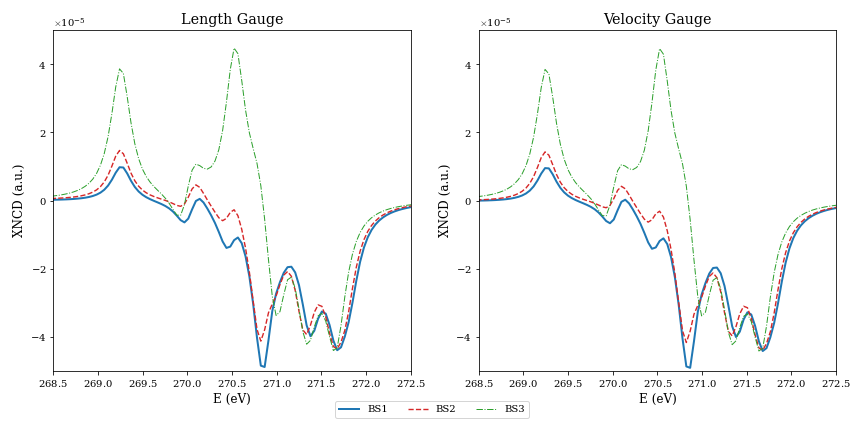

In [942]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 2.0},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.4},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.0},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xcd_bs1_es_lg_vcsame, xcd_bs1_es_lg_vcsame, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xcd_bs2_es_lg_vcsame, xcd_bs2_es_lg_vcsame, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xcd_bs3_es_lg_vcsame, xcd_bs3_es_lg_vcsame, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(268.5, 272.5)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XNCD (a.u.)")
ax1.set_ylim(-0.00005, 0.00005)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xcd_bs1_es_vg_vcsame, xcd_bs1_es_vg_vcsame, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xcd_bs2_es_vg_vcsame, xcd_bs2_es_vg_vcsame, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xcd_bs3_es_vg_vcsame, xcd_bs3_es_vg_vcsame, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(268.5, 272.5)
ax2.set_ylim(-0.00005, 0.00005)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XNCD (a.u.)")
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## Basis set convergence - Ground State, Left: LG XAS for different basis sets. Right: VG XAS for different basis sets

### BS1: C QZP 1 Diffuse, O and H TZP
### BS2: C and O QZP 1 Diffuse, H TZP
### BS3: C and O TZP Diffuse, H TZP

In [943]:
data_gas_bs1_gs_lg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_gs_lg"], color="black", label=r"GAS, BS1, LG", limits=pulse.crossings_E)
E_gas_xcd_bs1_gs_lg = data_gas_bs1_gs_lg.av_CD_energy_eV
xcd_bs1_gs_lg = data_gas_bs1_gs_lg.av_CD_spectrum
E_gas_xas_bs1_gs_lg = data_gas_bs1_gs_lg.av_lin_energy_eV
xas_bs1_gs_lg = data_gas_bs1_gs_lg.av_lin_spectrum

data_gas_bs1_gs_vg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs1_gs_vg"], color="black", label=r"GAS, BS1, VG", limits=pulse.crossings_E)
E_gas_xcd_bs1_gs_vg = data_gas_bs1_gs_vg.av_CD_energy_eV
xcd_bs1_gs_vg = data_gas_bs1_gs_vg.av_CD_spectrum
E_gas_xas_bs1_gs_vg = data_gas_bs1_gs_vg.av_lin_energy_eV
xas_bs1_gs_vg = data_gas_bs1_gs_vg.av_lin_spectrum

data_gas_bs2_gs_lg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_gs_lg"], color="black", label=r"GAS, BS2, LG", limits=pulse.crossings_E)
E_gas_xcd_bs2_gs_lg = data_gas_bs2_gs_lg.av_CD_energy_eV
xcd_bs2_gs_lg = data_gas_bs2_gs_lg.av_CD_spectrum
E_gas_xas_bs2_gs_lg = data_gas_bs2_gs_lg.av_lin_energy_eV
xas_bs2_gs_lg = data_gas_bs2_gs_lg.av_lin_spectrum

data_gas_bs2_gs_vg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs2_gs_vg"], color="black", label=r"GAS, BS2, VG", limits=pulse.crossings_E)
E_gas_xcd_bs2_gs_vg = data_gas_bs2_gs_vg.av_CD_energy_eV
xcd_bs2_gs_vg = data_gas_bs2_gs_vg.av_CD_spectrum
E_gas_xas_bs2_gs_vg = data_gas_bs2_gs_vg.av_lin_energy_eV
xas_bs2_gs_vg = data_gas_bs2_gs_vg.av_lin_spectrum

data_gas_bs3_gs_lg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_gs_lg"], color="black", label=r"GAS, BS3, LG", limits=pulse.crossings_E)
E_gas_xcd_bs3_gs_lg = data_gas_bs3_gs_lg.av_CD_energy_eV
xcd_bs3_gs_lg = data_gas_bs3_gs_lg.av_CD_spectrum
E_gas_xas_bs3_gs_lg = data_gas_bs3_gs_lg.av_lin_energy_eV
xas_bs3_gs_lg = data_gas_bs3_gs_lg.av_lin_spectrum

data_gas_bs3_gs_vg = Spectrum(project=json_data["path_spectra_camb3lyp_gas_carbon_bs3_gs_vg"], color="black", label=r"GAS, BS3, VG", limits=pulse.crossings_E)
E_gas_xcd_bs3_gs_vg = data_gas_bs3_gs_vg.av_CD_energy_eV
xcd_bs3_gs_vg = data_gas_bs3_gs_vg.av_CD_spectrum
E_gas_xas_bs3_gs_vg = data_gas_bs3_gs_vg.av_lin_energy_eV
xas_bs3_gs_vg = data_gas_bs3_gs_vg.av_lin_spectrum

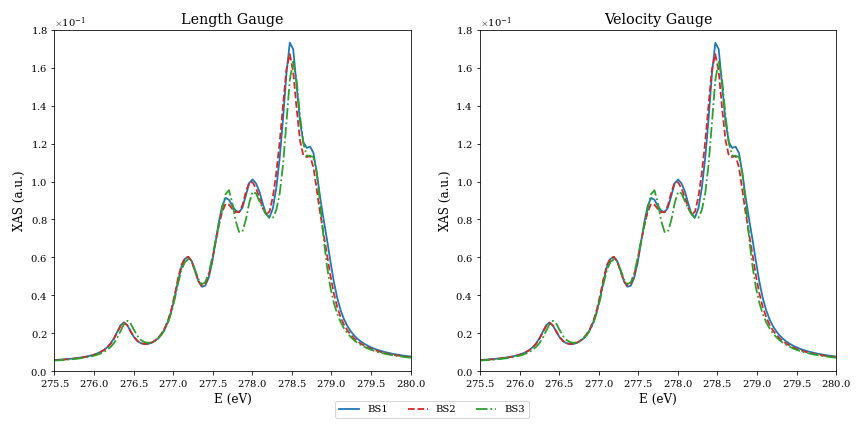

In [944]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 1.8},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.8},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.8},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xas_bs1_gs_lg, xas_bs1_gs_lg, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xas_bs2_gs_lg, xas_bs2_gs_lg, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xas_bs3_gs_lg, xas_bs3_gs_lg, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(275.5, 280)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XAS (a.u.)")
ax1.set_ylim(0.0, 0.18)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xas_bs1_gs_vg, xas_bs1_gs_vg, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xas_bs2_gs_vg, xas_bs2_gs_vg, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xas_bs3_gs_vg, xas_bs3_gs_vg, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(275.5, 280)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XAS (a.u.)")
ax2.set_ylim(0.0, 0.18)
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

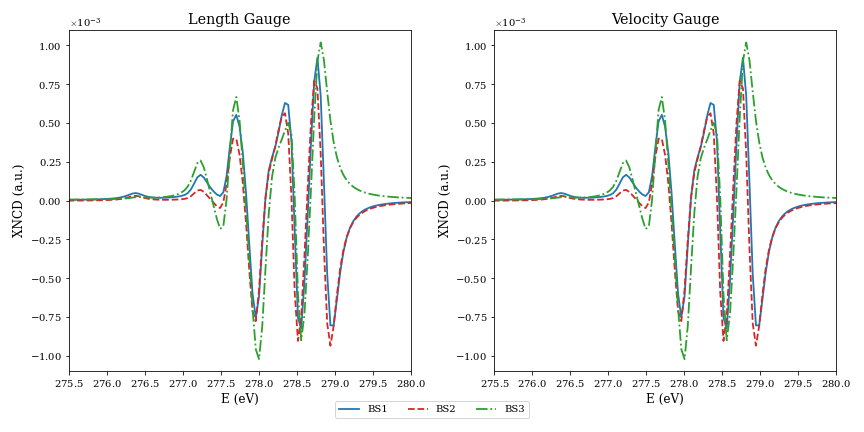

In [945]:
bs_styles = {
    "BS1": {"color": "#1f77b4", "linestyle": "-",  "linewidth": 1.8},
    "BS2": {"color": "#d62728", "linestyle": "--", "linewidth": 1.8},
    "BS3": {"color": "#2ca02c", "linestyle": "-.", "linewidth": 1.8},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

line_bs1, = ax1.plot(E_gas_xcd_bs1_gs_lg, xcd_bs1_gs_lg, label="BS1", **bs_styles["BS1"])
line_bs2, = ax1.plot(E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg, label="BS2", **bs_styles["BS2"])
line_bs3, = ax1.plot(E_gas_xcd_bs3_gs_lg, xcd_bs3_gs_lg, label="BS3", **bs_styles["BS3"])
ax1.set_xlim(275.5, 280)
ax1.set_xlabel("E (eV)")
ax1.set_ylabel("XNCD (a.u.)")
ax1.set_ylim(-0.0011, 0.0011)
ax1.set_title("Length Gauge")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

ax2.plot(E_gas_xcd_bs1_gs_vg, xcd_bs1_gs_vg, label="BS1", **bs_styles["BS1"])
ax2.plot(E_gas_xcd_bs2_gs_vg, xcd_bs2_gs_vg, label="BS2", **bs_styles["BS2"])
ax2.plot(E_gas_xcd_bs3_gs_vg, xcd_bs3_gs_vg, label="BS3", **bs_styles["BS3"])
ax2.set_xlim(275.5, 280)
ax2.set_ylim(-0.0011, 0.0011)
ax2.set_xlabel("E (eV)")
ax2.set_ylabel("XNCD (a.u.)")
ax2.set_title("Velocity Gauge")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_bs1, line_bs2, line_bs3]
labels = [line.get_label() for line in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## XCD: GS + ES for BS2 (largest basis set which converged with another basis set). Only Length Gauge (1 Figure: ground-state XCD (LG and VG) + excited-state XCD (LG+VG) with the largest basis set)

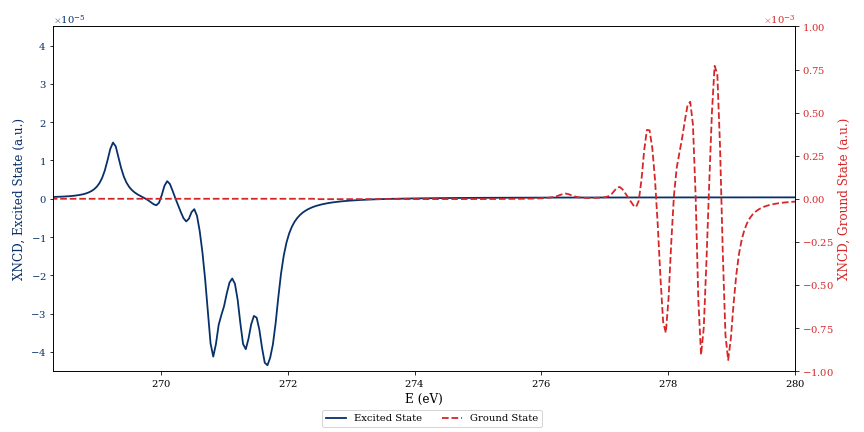

In [946]:
gs_style = {"color": "#d62728", "linestyle": "--", "linewidth": 1.8}
es_style = {"color": "#08306b", "linestyle": "-",  "linewidth": 1.8}

# Toggle to "break" the x-axis at a given range (// marks indicate the skip).
break_x_axis = False
# Energy span hidden from the axis (left panel ends at [0], right starts at [1]).
# A narrower window (e.g. 0.2–0.4 eV) removes the large 274→275 tick jump from a 1 eV gap.
break_x_range = (273.2, 275.7)

x_full = (268.3, 280.0)
es_ylim = (-0.000045, 0.000045)
gs_ylim = (-0.001, 0.001)

if break_x_axis:
    width_l = break_x_range[0] - x_full[0]
    width_r = x_full[1] - break_x_range[1]
    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(16, 6),
        gridspec_kw={"wspace": 0, "width_ratios": [width_l, width_r]},
    )
    axL_gs = axL.twinx()
    axR_gs = axR.twinx()

    # Same data on both panels; xlim selects the visible portion.
    line_es, = axL.plot(
        E_gas_xcd_bs2_es_lg_vcsame, xcd_bs2_es_lg_vcsame,
        label="Excited State", **es_style,
    )
    axR.plot(E_gas_xcd_bs2_es_lg_vcsame, xcd_bs2_es_lg_vcsame, **es_style)
    axL_gs.plot(E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg, **gs_style)
    line_gs, = axR_gs.plot(
        E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg,
        label="Ground State", **gs_style,
    )

    axL.set_xlim(x_full[0], break_x_range[0])
    axR.set_xlim(break_x_range[1], x_full[1])
    axL.set_ylim(*es_ylim);    axR.set_ylim(*es_ylim)
    axL_gs.set_ylim(*gs_ylim); axR_gs.set_ylim(*gs_ylim)

    # Hide inner spines and the corresponding tick labels.
    axL.spines["right"].set_visible(False)
    axL_gs.spines["right"].set_visible(False)
    axR.spines["left"].set_visible(False)
    axR_gs.spines["left"].set_visible(False)
    axL_gs.tick_params(axis="y", which="both", right=False, labelright=False)
    axR.tick_params(axis="y", which="both", left=False, labelleft=False)

    # Outer-only y-labels with matching colors.
    axL.set_ylabel("XNCD, Excited State (a.u.)", color=es_style["color"])
    axL.tick_params(axis="y", labelcolor=es_style["color"])
    axR_gs.set_ylabel("XNCD, Ground State (a.u.)", color=gs_style["color"])
    axR_gs.tick_params(axis="y", labelcolor=gs_style["color"])

    for ax in (axL, axR):
        ax.ticklabel_format(style="plain", axis="x", useMathText=True)
    axL.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
    axR_gs.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

    # Diagonal "//" cut marks on the inner spines.
    d = 0.5  # vertical/horizontal extent of the slanted lines
    cut_kwargs = dict(
        marker=[(-1, -d), (1, d)], markersize=10,
        linestyle="none", color="k", mec="k", mew=1, clip_on=False,
    )
    axL.plot([1, 1], [0, 1], transform=axL.transAxes, **cut_kwargs)
    axR.plot([0, 0], [0, 1], transform=axR.transAxes, **cut_kwargs)

    lines = [line_es, line_gs]
    labels = [line.get_label() for line in lines]
    fig.legend(
        lines, labels, loc="lower center",
        bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=True,
    )
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    fig.text(
        0.5,
        0.09,
        "E (eV)",
        ha="center",
        va="top",
        fontsize=mpl.rcParams["axes.labelsize"],
    )
    plt.show()
else:
    fig, ax1 = plt.subplots(figsize=(12, 6))

    line_es, = ax1.plot(
        E_gas_xcd_bs2_es_lg_vcsame, xcd_bs2_es_lg_vcsame,
        label="Excited State", **es_style,
    )
    ax1.set_xlim(*x_full)
    ax1.set_xlabel("E (eV)")
    ax1.set_ylabel("XNCD, Excited State (a.u.)", color=es_style["color"])
    ax1.tick_params(axis="y", labelcolor=es_style["color"])
    ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
    ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

    ax2 = ax1.twinx()
    line_gs, = ax2.plot(
        E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg,
        label="Ground State", **gs_style,
    )
    ax2.set_ylabel("XNCD, Ground State (a.u.)", color=gs_style["color"])
    ax2.tick_params(axis="y", labelcolor=gs_style["color"])
    ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

    ax1.set_ylim(*es_ylim)
    ax2.set_ylim(*gs_ylim)

    lines = [line_es, line_gs]
    labels = [line.get_label() for line in lines]
    fig.legend(
        lines, labels, loc="lower center",
        bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=True,
    )
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()

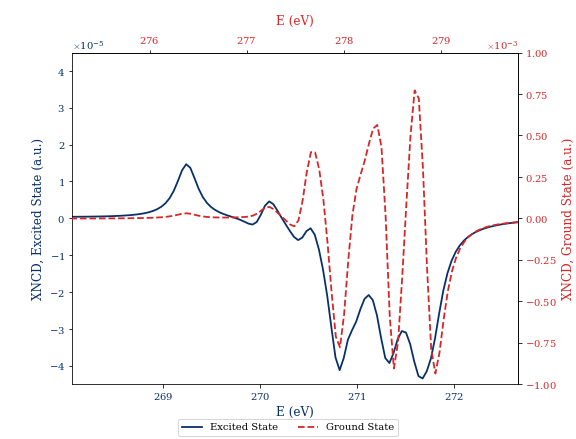

In [947]:
# Single panel, four independent scales: bottom X + left Y (ES), top X + right Y (GS).
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

gs_style = {"color": "#d62728", "linestyle": "--", "linewidth": 1.8}
es_style = {"color": "#08306b", "linestyle": "-",  "linewidth": 1.8}

xlim_gs = (275.2, 279.8)
xlim_es = (xlim_gs[0] - 7.13467, xlim_gs[1] - 7.13467)
es_ylim = (-0.000045, 0.000045)
gs_ylim = (-0.001, 0.001)

fig, ax_es = plt.subplots(figsize=(8, 6.1))

line_es, = ax_es.plot(
    E_gas_xcd_bs2_es_lg_vcsame,
    xcd_bs2_es_lg_vcsame,
    label="Excited State",
    **es_style,
)
ax_es.set_xlim(*xlim_es)
ax_es.set_ylim(*es_ylim)
ax_es.set_xlabel("E (eV)", color=es_style["color"])
ax_es.set_ylabel("XNCD, Excited State (a.u.)", color=es_style["color"])
ax_es.tick_params(axis="y", labelcolor=es_style["color"])
ax_es.tick_params(axis="x", labelcolor=es_style["color"])
ax_es.ticklabel_format(style="plain", axis="x", useMathText=True)
ax_es.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Second axes, same bounding box: top X + right Y for GS (independent limits).
ax_gs = inset_axes(
    ax_es,
    width="100%",
    height="100%",
    bbox_to_anchor=(0, 0, 1, 1),
    bbox_transform=ax_es.transAxes,
    loc="lower left",
    borderpad=0,
)
ax_gs.patch.set_visible(False)
for _sp in ("bottom", "left"):
    ax_gs.spines[_sp].set_visible(False)
ax_gs.xaxis.tick_top()
ax_gs.xaxis.set_label_position("top")
ax_gs.yaxis.tick_right()
ax_gs.yaxis.set_label_position("right")
ax_gs.tick_params(axis="x", bottom=False, labelbottom=False, top=True, labeltop=True)
ax_gs.tick_params(axis="y", left=False, labelleft=False, right=True, labelright=True)

line_gs, = ax_gs.plot(
    E_gas_xcd_bs2_gs_lg,
    xcd_bs2_gs_lg,
    label="Ground State",
    **gs_style,
)
ax_gs.set_xlim(*xlim_gs)
ax_gs.set_ylim(*gs_ylim)
ax_gs.set_xlabel("E (eV)", labelpad=10, color=gs_style["color"])
ax_gs.set_ylabel("XNCD, Ground State (a.u.)", color=gs_style["color"])
ax_gs.tick_params(axis="y", labelcolor=gs_style["color"])
ax_gs.tick_params(axis="x", labelcolor=gs_style["color"])
ax_gs.ticklabel_format(style="plain", axis="x", useMathText=True)
ax_gs.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

lines = [line_es, line_gs]
labels = [ln.get_label() for ln in lines]
fig.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=2,
    frameon=True,
)

#plt.tight_layout(rect=(0, 0.06, 1, 1))

_dx_sci_pts = 40.0  # horizontal nudge for ×10^n (points); adjust if needed
for _ax, _sign in (
    (ax1, -1),
    (ax1_right, 1),
    (ax2, -1),
    (ax2_right, 1),
):
    _ot = _ax.yaxis.get_offset_text()
    _ot.set_transform(
        _ot.get_transform()
        + ScaledTranslation(_sign * _dx_sci_pts / 72.0, 0, fig.dpi_scale_trans)
    )


## Two panels XAS (exp vs theory), XCD (exp vs theory)

In [948]:
data_exp_XAS_piancastelli = np.genfromtxt(json_data["path_exp_xas_carbon_piancastelli"])
data_exp_XAS_turchini = np.genfromtxt(json_data["path_exp_xas_carbon_turchini"])
data_exp_XCD_turchini = np.genfromtxt(json_data["path_exp_xcd_carbon_turchini"])

E_exp_XAS_piancastelli, XAS_exp_piancastelli = data_exp_XAS_piancastelli[:, 0], data_exp_XAS_piancastelli[:, 1]
E_exp_XAS_turchini, XAS_exp_turchini = data_exp_XAS_turchini[:, 0]-0.1, data_exp_XAS_turchini[:, 1]
E_exp_XCD_turchini, XCD_exp_turchini = data_exp_XCD_turchini[:, 0]-0.1, data_exp_XCD_turchini[:, 1]

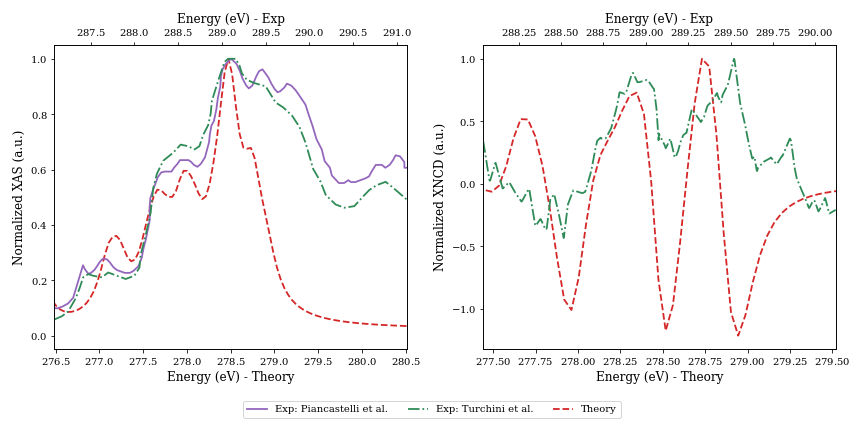

In [949]:
fig = plt.figure(figsize=(12, 6))

# Consistent styles by source across all subplots
style_piancastelli = {"color": "tab:purple", "linestyle": "-", "linewidth": 1.8}
style_turchini = {"color": "#2E8B57", "linestyle": "-.", "linewidth": 1.8}
style_theory = {"color": "#d62728", "linestyle": "--", "linewidth": 1.8}

# Subplot 1: XAS (single Y axis)
ax1_calc = fig.add_subplot(1, 2, 1)
ax1_exp = ax1_calc.twiny()

# Calculated spectrum -> bottom X + shared Y
line_calc_xas, = ax1_calc.plot(
    E_gas_xas_bs2_gs_lg,
    xas_bs2_gs_lg / np.max(xas_bs2_gs_lg),
    label="Theory",
    **style_theory,
)
ax1_calc.set_xlim(E_exp_XAS_turchini.min() - 10.6, E_exp_XAS_turchini.max() - 10.6)
ax1_calc.set_xlabel("Energy (eV) - Theory")
ax1_calc.set_ylabel("Normalized XAS (a.u.)")

# Experimental spectra -> top X + shared Y
line_exp_pia, = ax1_exp.plot(
    E_exp_XAS_piancastelli,
    XAS_exp_piancastelli / np.max(XAS_exp_piancastelli),
    label="Exp: Piancastelli et al.",
    **style_piancastelli,
)
line_exp_tur_xas, = ax1_exp.plot(
    E_exp_XAS_turchini,
    XAS_exp_turchini / np.max(XAS_exp_turchini),
    label="Exp: Turchini et al.",
    **style_turchini,
)
ax1_exp.set_xlim(E_exp_XAS_turchini.min(), E_exp_XAS_turchini.max())
ax1_exp.set_xlabel("Energy (eV) - Exp")

# Scientific notation style as in previous notebook plots
ax1_calc.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
for ax in (ax1_calc, ax1_exp):
    ax.ticklabel_format(style="plain", axis="x", useMathText=True)

# Subplot 2: XCD (single Y axis)
ax2_calc = fig.add_subplot(1, 2, 2)
ax2_exp = ax2_calc.twiny()

# Calculated spectrum -> bottom X + shared Y
line_calc_xcd, = ax2_calc.plot(
    E_gas_xcd_bs2_gs_lg,
    xcd_bs2_gs_lg / np.max(xcd_bs2_gs_lg),
    label="Theory",
    **style_theory,
)
ax2_calc.set_xlim(E_exp_XCD_turchini.min() - 10.6, E_exp_XCD_turchini.max() - 10.6)
ax2_calc.set_xlabel("Energy (eV) - Theory")
ax2_calc.set_ylabel("Normalized XNCD (a.u.)")

# Experimental spectrum -> top X + shared Y
line_exp_tur_xcd, = ax2_exp.plot(
    E_exp_XCD_turchini,
    XCD_exp_turchini / np.max(XCD_exp_turchini),
    label="Exp: Turchini et al.",
    **style_turchini,
)
ax2_exp.set_xlim(E_exp_XCD_turchini.min(), E_exp_XCD_turchini.max())
ax2_exp.set_xlabel("Energy (eV) - Exp")

ax2_calc.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
for ax in (ax2_calc, ax2_exp):
    ax.ticklabel_format(style="plain", axis="x", useMathText=True)

# Single legend for the full figure (bottom)
fig.legend(
    handles=[line_exp_pia, line_exp_tur_xas, line_calc_xas],
    labels=["Exp: Piancastelli et al.", "Exp: Turchini et al.", "Theory"],
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.02),
)

fig.tight_layout(rect=(0, 0.08, 1, 1))

## AMS vs WaveT for ground-state XAS and XCD (two panels, Supporting Information) with the largest basis set

In [950]:
E_min, E_max = 275.5, 280

data_xas_sticks_ams = np.genfromtxt(json_data["path_ams_xas_carbon_codiff"])
E_xas_ams, xas_ams_sticks = data_xas_sticks_ams[:, 0], data_xas_sticks_ams[:, 1]

data_xcd_sticks_ams = np.genfromtxt(json_data["path_ams_xcd_carbon_codiff"])
E_xcd_ams, xcd_ams_sticks = data_xcd_sticks_ams[:, 0], data_xcd_sticks_ams[:, 1]

E_common = np.linspace(E_min, E_max, 1000)

def gaussian(x, mu, sigma=0.105):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

xas_ams = np.zeros(E_common.shape)
xcd_ams = np.zeros(E_common.shape)

n_roots = 17

for i, E in enumerate(E_xas_ams):
    if i < n_roots:
        xas_ams += xas_ams_sticks[i]*gaussian(E_common, E)
        xcd_ams += xcd_ams_sticks[i]*gaussian(E_common, E)

xas_ams += xas_bs2_gs_lg[np.argmin(np.abs(E_gas_xas_bs2_gs_lg - E_min))]
xcd_ams += xcd_bs2_gs_lg[np.argmin(np.abs(E_gas_xcd_bs2_gs_lg - E_min))]
xas_ams = xas_ams* np.max(xas_bs2_gs_lg) / np.max(xas_ams)
xcd_ams = xcd_ams* np.max(xcd_bs2_gs_lg) / np.max(xcd_ams)

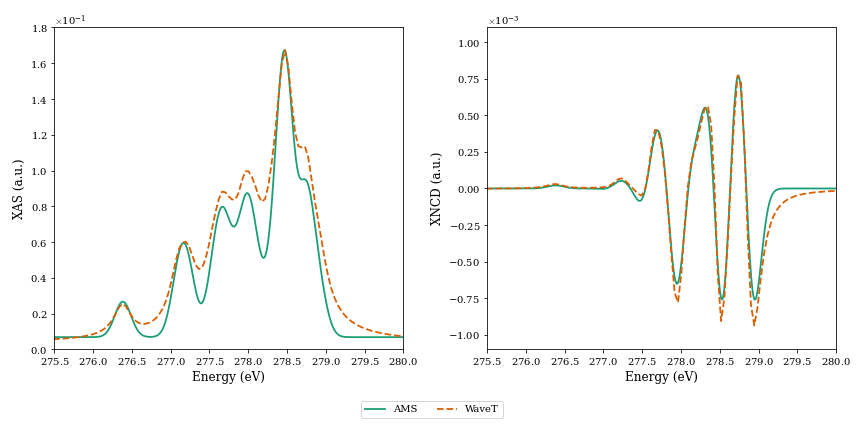

In [951]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# High-contrast styles for similar curves
style_ams = {"color": "#1b9e77", "linestyle": "-", "linewidth": 1.8}
style_wavet = {"color": "#d95f02", "linestyle": "--", "linewidth": 1.8}

# XAS
line_ams_xas, = ax1.plot(E_common, xas_ams, label="AMS", **style_ams)
line_wavet_xas, = ax1.plot(E_gas_xas_bs2_gs_lg, xas_bs2_gs_lg, label="WaveT", **style_wavet)
ax1.set_xlim(E_min, E_max)
ax1.set_ylim(0.0, 0.18)
ax1.set_xlabel("Energy (eV)")
ax1.set_ylabel("XAS (a.u.)")
ax1.ticklabel_format(style="plain", axis="x", useMathText=True)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# XCD
ax2.plot(E_common, xcd_ams, label="AMS", **style_ams)
ax2.plot(E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg, label="WaveT", **style_wavet)
ax2.set_xlim(E_min, E_max)
ax2.set_ylim(-0.0011, 0.0011)
ax2.set_xlabel("Energy (eV)")
ax2.set_ylabel("XNCD (a.u.)")
ax2.ticklabel_format(style="plain", axis="x", useMathText=True)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Single legend at bottom of canvas
fig.legend(
    handles=[line_ams_xas, line_wavet_xas],
    labels=["AMS", "WaveT"],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.02),
)

fig.tight_layout(rect=(0, 0.08, 1, 1))

## LG vs VG for XAS with the largest basis set (Supporting Information) + residual

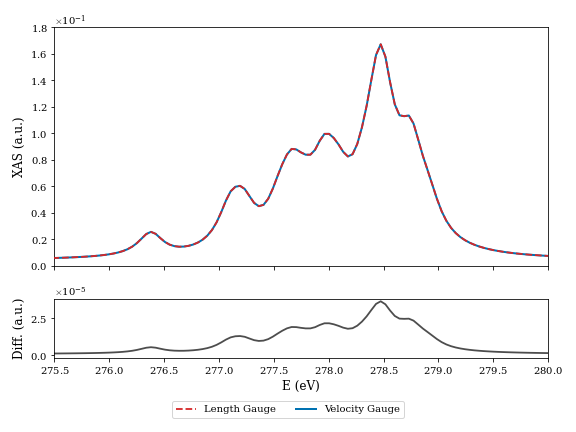

In [952]:
fig, (ax_main, ax_res) = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]},
)

# Keep BS2-like style for gs_lg (dashed) with new, unused colors
style_lg = {"color": "#d62728", "linestyle": "--", "linewidth": 1.8, "alpha": 1.0, "zorder": 3}
style_vg = {"color": "#0072B2", "linestyle": "-", "linewidth": 2.0, "alpha": 1.0, "zorder": 2}

line_lg, = ax_main.plot(E_gas_xas_bs2_gs_lg, xas_bs2_gs_lg, label="Length Gauge", **style_lg)
line_vg, = ax_main.plot(E_gas_xas_bs2_gs_vg, xas_bs2_gs_vg, label="Velocity Gauge", **style_vg)
ax_main.set_xlim(275.5, 280)
ax_main.set_ylim(0.0, 0.18)
ax_main.set_ylabel("XAS (a.u.)")
ax_main.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Residuals panel (small rectangle below)
residual = xas_bs2_gs_lg - xas_bs2_gs_vg
ax_res.plot(E_gas_xas_bs2_gs_lg, residual, color="#4d4d4d", linestyle="-", linewidth=1.8)
ax_res.set_xlim(275.5, 280)
ax_res.set_xlabel("E (eV)")
ax_res.set_ylabel("Diff. (a.u.)")
ax_res.ticklabel_format(style="plain", axis="x", useMathText=True)
ax_res.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Legend at bottom of canvas
fig.legend(
    handles=[line_lg, line_vg],
    labels=["Length Gauge", "Velocity Gauge"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
)

fig.tight_layout(rect=(0, 0.06, 1, 1))

## LG vs VG for XCD with the largest basis set (Supporting Information) + residuals

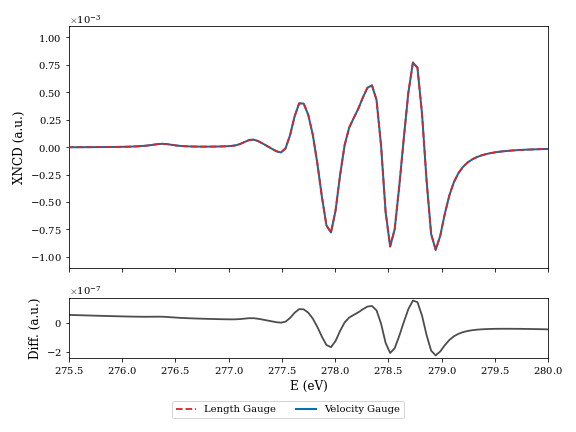

In [953]:
fig, (ax_main, ax_res) = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]},
)

# Keep BS2-like style for gs_lg (dashed) with new, unused colors
style_lg = {"color": "#d62728", "linestyle": "--", "linewidth": 1.8, "alpha": 1.0, "zorder": 3}
style_vg = {"color": "#0072B2", "linestyle": "-", "linewidth": 2.0, "alpha": 1.0, "zorder": 2}

line_lg, = ax_main.plot(E_gas_xcd_bs2_gs_lg, xcd_bs2_gs_lg, label="Length Gauge", **style_lg)
line_vg, = ax_main.plot(E_gas_xcd_bs2_gs_vg, xcd_bs2_gs_vg, label="Velocity Gauge", **style_vg)
ax_main.set_xlim(275.5, 280)
ax_main.set_ylim(-0.0011, 0.0011)
ax_main.set_ylabel("XNCD (a.u.)")
ax_main.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Residuals panel (small rectangle below)
residual = xcd_bs2_gs_lg - xcd_bs2_gs_vg
ax_res.plot(E_gas_xcd_bs2_gs_lg, residual, color="#4d4d4d", linestyle="-", linewidth=1.8)
ax_res.set_xlim(275.5, 280)
ax_res.set_xlabel("E (eV)")
ax_res.set_ylabel("Diff. (a.u.)")
ax_res.ticklabel_format(style="plain", axis="x", useMathText=True)
ax_res.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

# Legend at bottom of canvas
fig.legend(
    handles=[line_lg, line_vg],
    labels=["Length Gauge", "Velocity Gauge"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
)

fig.tight_layout(rect=(0, 0.06, 1, 1))